# 02 — Correlations and portfolio risk

Question answered: **how much of my 'hedge' is an illusion?** Long GOOGL (long-growth) + short-SPCX spread (short-growth) partially cancel. Long-run Pearson vs EWMA (λ=0.94, RiskMetrics) weighting the last ~30 days: when they diverge, the regime is shifting.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.viz import tufte_style, direct_label_lines, corr_heatmap, pnl_distribution, headline, PALETTE, GOOD, BAD, NEUTRAL
tufte_style()

In [2]:
from src.risk.metrics import log_returns, corr_matrix, ewma_corr, summary_table
prices = pd.read_parquet("../data/universe_prices.parquet").dropna()
rets = log_returns(prices)
summary = summary_table(prices)
summary

,vol_annua,beta_vs_SP500,max_drawdown,ret_tot_periodo
GOOGL,0.3046,1.1176,-0.2981,1.0693
TSLA,0.6071,2.3625,-0.5377,1.2274
NDAQ,0.2431,0.8188,-0.2176,0.5478
HOOD,0.7192,2.8227,-0.5726,2.9979
VIRT,0.3348,0.6623,-0.2783,1.5797
GS,0.3147,1.4298,-0.3090,1.4799
MS,0.3034,1.3728,-0.2924,1.3759
RKLB,0.9029,2.5823,-0.4815,21.5033
ASTS,1.0760,2.6601,-0.5409,7.2575
LMT,0.2559,0.1592,-0.3179,0.2420


## Heatmaps: structural correlation (2y) vs current regime (EWMA)

Reading guide: TSLA is the best available proxy for the volatility SPCX will have (same key-man risk). If GOOGL-TSLA EWMA > 0.6, the 'Musk beta' contaminates the defensive tranche too — lower your hedging expectations. The ^VIX row should be deep blue (negative) against everything: a sanity check on the whole matrix.

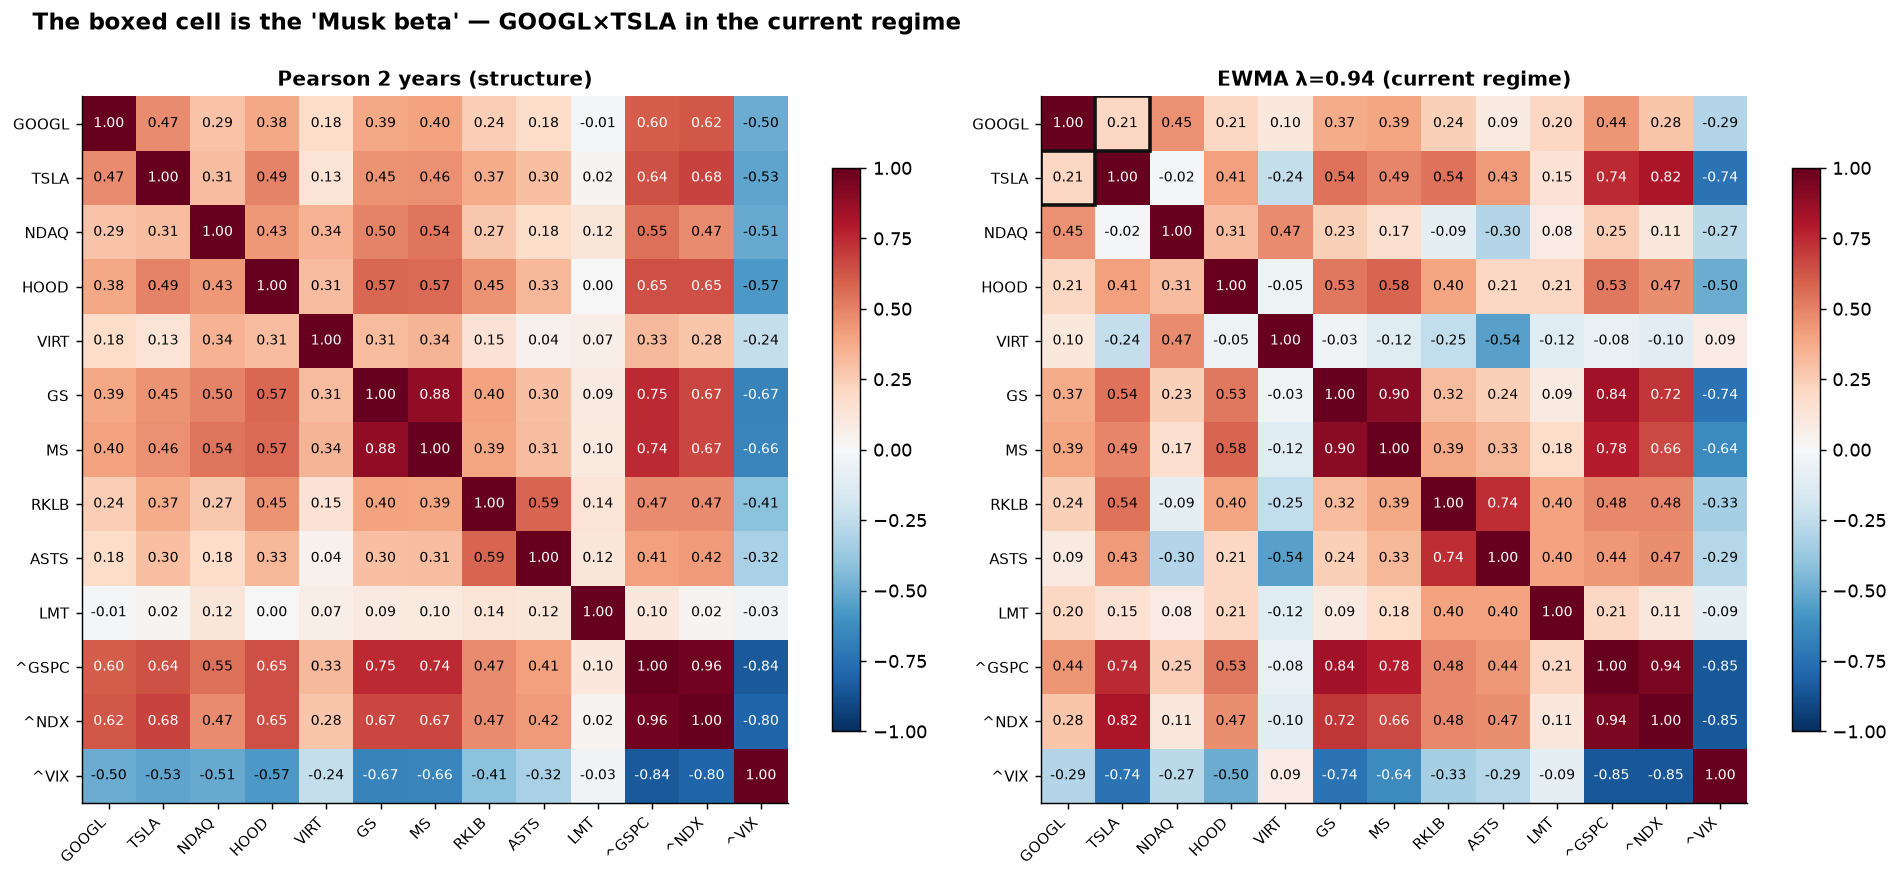

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
corr_heatmap(axes[0], corr_matrix(rets), "Pearson 2 years (structure)")
corr_heatmap(axes[1], ewma_corr(rets), "EWMA λ=0.94 (current regime)", highlight=("GOOGL", "TSLA"))
fig.suptitle("The boxed cell is the 'Musk beta' — GOOGL×TSLA in the current regime", x=0.02, ha="left", fontweight="bold", fontsize=12.5, y=1.0)
fig.tight_layout(); fig.savefig("../assets/chart_corr.png", bbox_inches="tight"); plt.show()

## Rolling 60d correlation, GOOGL vs market

If it rises toward 1 in drawdowns (it almost always does), diversification vanishes exactly when needed — which is why the plan's only true hedge is the spread's hard cap, not correlation.

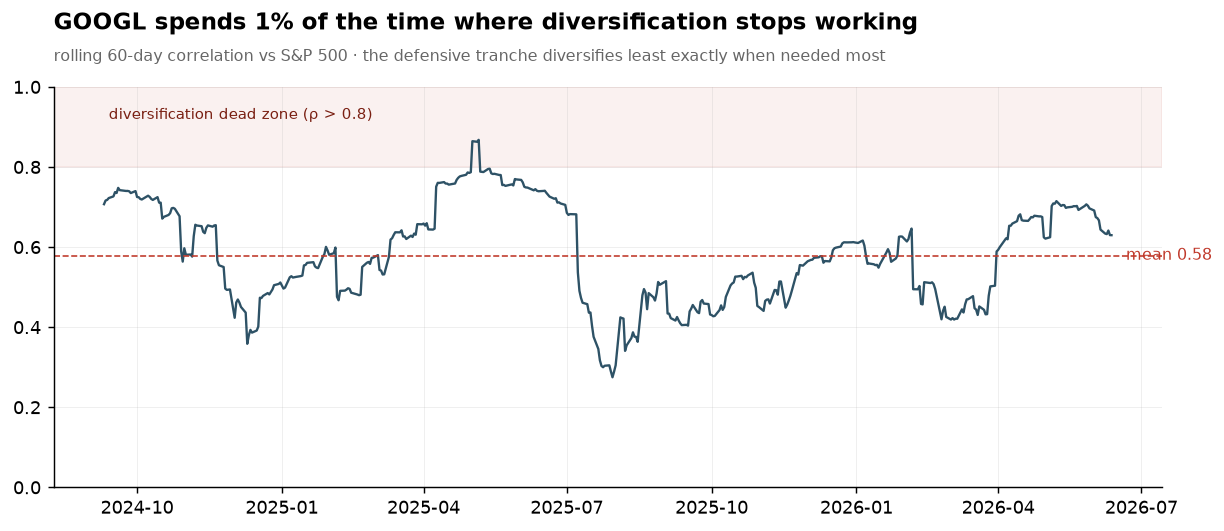

In [4]:
roll = rets["GOOGL"].rolling(60).corr(rets["^GSPC"]).dropna()
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_ylim(0, 1)
ax.axhspan(0.8, 1.0, color=BAD, alpha=0.07)
ax.annotate("diversification dead zone (ρ > 0.8)", (roll.index[3], 0.92), fontsize=8.5, color="#7a1f12")
ax.plot(roll.index, roll.values, lw=1.3)
ax.axhline(roll.mean(), color=PALETTE[1], lw=0.9, ls="--")
ax.annotate(f"mean {roll.mean():.2f}", (roll.index[-1], roll.mean()), xytext=(8, 0), textcoords="offset points", color=PALETTE[1], fontsize=9, va="center")
headline(ax, f"GOOGL spends {(roll > 0.8).mean():.0%} of the time where diversification stops working",
         "rolling 60-day correlation vs S&P 500 · the defensive tranche diversifies least exactly when needed most")
fig.savefig("../assets/chart_rolling_corr.png", bbox_inches="tight"); plt.show()

## Plan risk ledger

| Position | Risk driver | Cap |
|---|---|---|
| GOOGL (defensive tranche) | beta × market drawdown | soft (thesis stop -15%) |
| SPCX put spread | premium paid | **hard** |
| Cash reserve | none | hard |

The plan's true VaR comes from the Monte Carlo in notebook 03; these correlations are its qualitative inputs.